# 06 — Forest Models: Random Forest & XGBoost

Trains and evaluates Random Forest and XGBoost classifiers across the three feature spaces built in notebook 03.

The vault split is **locked** and not touched here — it is reserved for final evaluation in notebook 08.

## Setup

In [31]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from config import TARGET_CLASSES, RANDOM_STATE

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
os.makedirs('../figures/06-Forests', exist_ok=True)

## Load Data

In [32]:
X_train      = joblib.load('../data/processed/X_train.pkl')
y_train      = joblib.load('../data/processed/y_train.pkl')
feature_sets = joblib.load('../data/processed/feature_sets.pkl')

print(f'Train : {X_train.shape}')
print(f'\nClass distribution (train):')
vc = pd.Series(y_train.values).value_counts().sort_index()
for idx, cnt in vc.items():
    print(f'  {idx} ({TARGET_CLASSES[idx]:<25}) -- {cnt} samples')
print(f'\nFeature sets loaded: {list(feature_sets.keys())}')

Train : (1688, 11)

Class distribution (train):
  0 (Insufficient_Weight      ) -- 218 samples
  1 (Normal_Weight            ) -- 229 samples
  2 (Overweight_Level_I       ) -- 232 samples
  3 (Overweight_Level_II      ) -- 232 samples
  4 (Obesity_Type_I           ) -- 281 samples
  5 (Obesity_Type_II          ) -- 237 samples
  6 (Obesity_Type_III         ) -- 259 samples

Feature sets loaded: ['original', 'pca', 'lasso']


## Class Balance Strategy

Both models handle class imbalance differently:
- **Random Forest** accepts `class_weight='balanced'` directly, which adjusts splits based on class frequency.
- **XGBoost** uses `sample_weight` passed at fit time via `compute_sample_weight('balanced')`.

In [33]:
from sklearn.utils.class_weight import compute_sample_weight

preview_weights = compute_sample_weight('balanced', y_train)
print(f'Sample weight range: {preview_weights.min():.3f} -> {preview_weights.max():.3f}')
print(f'(Higher = rarer class, lower = more common class)')

Sample weight range: 0.858 -> 1.106
(Higher = rarer class, lower = more common class)


## Cross-Validation Setup

**Hierarchical CV scheme:**
- 20% of the total dataset is held out as the **vault** â€” never loaded here
- All model selection happens via **5-fold stratified CV** on the remaining 80%
- Transformers are **re-fit inside each fold** on that fold's training portion only â€” prevents data leakage
- Sample weights are recomputed fresh inside each fold

In [34]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.base import clone

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_evaluate(X_raw, y, model, transformer=None, use_sample_weight=False, verbose=False):
    """
    5-fold stratified CV.

    Parameters
    ----------
    X_raw            : raw feature array (pre-transformation)
    y                : labels
    model            : sklearn-compatible classifier
    transformer      : optional transformer re-fit per fold to prevent leakage
    use_sample_weight: pass balanced sample weights at fit time
    """
    y_arr = np.array(y)
    accs, f1s = [], []

    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_raw, y_arr)):
        X_tr, X_val = X_raw[tr_idx], X_raw[val_idx]
        y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

        if transformer is not None:
            t = clone(transformer)
            X_tr  = t.fit_transform(X_tr, y_tr)
            X_val = t.transform(X_val)

        fit_kwargs = {}
        if use_sample_weight:
            fit_kwargs['sample_weight'] = compute_sample_weight('balanced', y_tr)

        m = clone(model)
        m.fit(X_tr, y_tr, **fit_kwargs)
        y_pred = m.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        if verbose:
            print(f'  Fold {fold+1}: acc={accs[-1]:.4f}  macro-F1={f1s[-1]:.4f}')

    return {
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'f1_mean' : np.mean(f1s),  'f1_std' : np.std(f1s),
    }

print('CV helper ready -- StratifiedKFold(n_splits=5)')

CV helper ready -- StratifiedKFold(n_splits=5)


## Models

### Random Forest
An ensemble of decision trees trained on random subsets of features and data. `class_weight='balanced'` handles imbalance natively.

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

### XGBoost
Gradient boosted trees. Uses `sample_weight` at fit time for class balance since it does not accept `class_weight` directly.

In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## Run Cross-Validation

In [37]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

cv_transformers = {
    'original': None,
    'pca'     : PCA(n_components=0.95, random_state=RANDOM_STATE),
    'lasso'   : SelectFromModel(
                    LogisticRegression(solver='saga', l1_ratio=1, C=0.1,
                                       max_iter=2000, random_state=RANDOM_STATE,
                                       class_weight='balanced'),
                    threshold=1e-6
                ),
}

models = {
    'Random Forest': (rf, False),   # class_weight handled internally
    'XGBoost'      : (xgb, True),   # needs sample_weight at fit time
}

cv_results = {}

for model_name, (model, use_sw) in models.items():
    cv_results[model_name] = {}
    for fs_name, fs in feature_sets.items():
        print(f'\n-- {model_name} on \'{fs_name}\' ({fs["n_features"]} features) --')
        scores = cv_evaluate(
            X_train.values, y_train, model,
            transformer=cv_transformers[fs_name],
            use_sample_weight=use_sw, verbose=True
        )
        cv_results[model_name][fs_name] = scores
        print(f'  -> Accuracy : {scores["acc_mean"]:.4f} +/- {scores["acc_std"]:.4f}')
        print(f'  -> Macro F1 : {scores["f1_mean"]:.4f} +/- {scores["f1_std"]:.4f}')


-- Random Forest on 'original' (11 features) --
  Fold 1: acc=0.7337  macro-F1=0.7319
  Fold 2: acc=0.7456  macro-F1=0.7413
  Fold 3: acc=0.7219  macro-F1=0.7236
  Fold 4: acc=0.7596  macro-F1=0.7485
  Fold 5: acc=0.7507  macro-F1=0.7429
  -> Accuracy : 0.7423 +/- 0.0132
  -> Macro F1 : 0.7376 +/- 0.0088

-- Random Forest on 'pca' (7 features) --
  Fold 1: acc=0.6982  macro-F1=0.6925
  Fold 2: acc=0.6686  macro-F1=0.6598
  Fold 3: acc=0.6036  macro-F1=0.5982
  Fold 4: acc=0.6291  macro-F1=0.6155
  Fold 5: acc=0.6766  macro-F1=0.6618
  -> Accuracy : 0.6552 +/- 0.0342
  -> Macro F1 : 0.6456 +/- 0.0341

-- Random Forest on 'lasso' (10 features) --
  Fold 1: acc=0.7189  macro-F1=0.7157
  Fold 2: acc=0.7337  macro-F1=0.7294
  Fold 3: acc=0.7012  macro-F1=0.6987
  Fold 4: acc=0.7537  macro-F1=0.7439
  Fold 5: acc=0.7507  macro-F1=0.7429
  -> Accuracy : 0.7317 +/- 0.0197
  -> Macro F1 : 0.7261 +/- 0.0172

-- XGBoost on 'original' (11 features) --
  Fold 1: acc=0.7485  macro-F1=0.7475
  Fold 

## Results Summary

In [38]:
summary_rows = []
for model_name, fs_scores in cv_results.items():
    for fs_name, scores in fs_scores.items():
        summary_rows.append({
            'Model'       : model_name,
            'Feature Set' : fs_name,
            'N Features'  : feature_sets[fs_name]['n_features'],
            'CV Accuracy' : f"{scores['acc_mean']:.4f} +/- {scores['acc_std']:.4f}",
            'CV Macro F1' : f"{scores['f1_mean']:.4f} +/- {scores['f1_std']:.4f}",
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

        Model Feature Set  N Features       CV Accuracy       CV Macro F1
Random Forest    original          11 0.7423 +/- 0.0132 0.7376 +/- 0.0088
Random Forest         pca           7 0.6552 +/- 0.0342 0.6456 +/- 0.0341
Random Forest       lasso          10 0.7317 +/- 0.0197 0.7261 +/- 0.0172
      XGBoost    original          11 0.7162 +/- 0.0254 0.7119 +/- 0.0259
      XGBoost         pca           7 0.6244 +/- 0.0278 0.6169 +/- 0.0266
      XGBoost       lasso          10 0.7204 +/- 0.0206 0.7149 +/- 0.0219


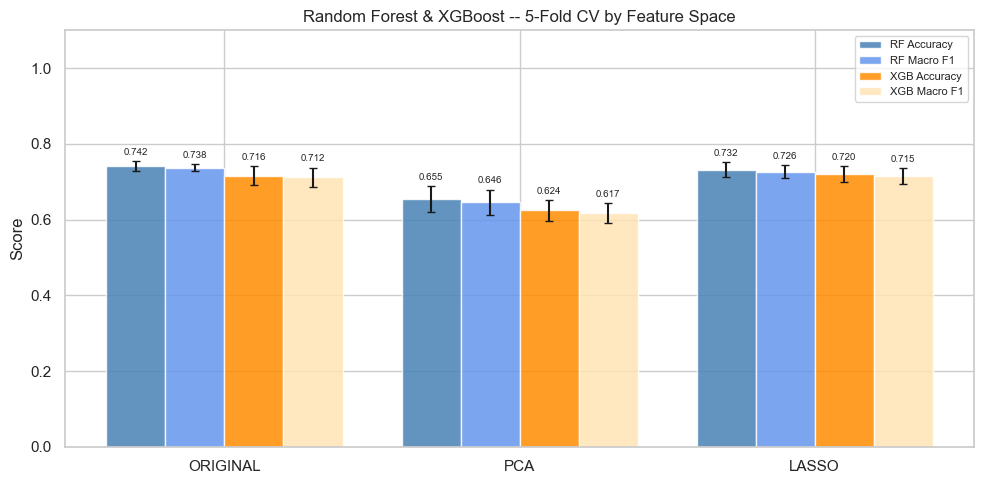

In [39]:
fs_labels = list(feature_sets.keys())
x     = np.arange(len(fs_labels))
width = 0.2
colors = {"Random Forest": ("steelblue", "cornflowerblue"),
          "XGBoost"      : ("darkorange", "moccasin")}

fig, ax = plt.subplots(figsize=(10, 5))
offsets = [-1.5, -0.5, 0.5, 1.5]
bars_meta = [
    ("Random Forest", "acc", offsets[0], colors["Random Forest"][0], "RF Accuracy"),
    ("Random Forest", "f1",  offsets[1], colors["Random Forest"][1], "RF Macro F1"),
    ("XGBoost",       "acc", offsets[2], colors["XGBoost"][0],       "XGB Accuracy"),
    ("XGBoost",       "f1",  offsets[3], colors["XGBoost"][1],       "XGB Macro F1"),
]

for model_name, metric, offset, color, label in bars_meta:
    means = [cv_results[model_name][fs][f"{metric}_mean"] for fs in fs_labels]
    stds  = [cv_results[model_name][fs][f"{metric}_std"]  for fs in fs_labels]
    bars = ax.bar(x + offset * width, means, width, yerr=stds, capsize=3,
                  label=label, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f.upper() for f in fs_labels])
ax.set_ylabel("Score")
ax.set_title("Random Forest & XGBoost -- 5-Fold CV by Feature Space")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/06-Forests/forests_cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Save Results

In [40]:
joblib.dump(cv_results, '../data/processed/cv_results_forests.pkl')

# Re-train on full training set for use in notebook 08
trained_models = {}
for model_name, (model, use_sw) in models.items():
    trained_models[model_name] = {}
    for fs_name, fs in feature_sets.items():
        m = clone(model)
        fit_kwargs = {}
        if use_sw:
            fit_kwargs['sample_weight'] = compute_sample_weight('balanced', y_train)
        m.fit(fs['X_train'], y_train.values, **fit_kwargs)
        trained_models[model_name][fs_name] = m
        print(f'Trained {model_name} ({fs_name})')

joblib.dump(trained_models, '../data/processed/trained_models_forests.pkl')
print('\nResults and models saved to data/processed/')

Trained Random Forest (original)
Trained Random Forest (pca)
Trained Random Forest (lasso)
Trained XGBoost (original)
Trained XGBoost (pca)
Trained XGBoost (lasso)

Results and models saved to data/processed/


## Hyperparameter Tuning

Uses `RandomizedSearchCV` with the same 5-fold stratified CV to find better hyperparameters
for each model and feature space. Best parameters are selected on training folds only.

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

rf_param_dist = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf' : randint(1, 10),
    'max_features'     : ['sqrt', 'log2'],
}

xgb_param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(3, 10),
    'learning_rate'   : uniform(0.01, 0.3),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 6),
}

print('Search spaces defined.')

Search spaces defined.


In [42]:
def tune_and_evaluate(X_raw, y, model, param_dist, transformer=None,
                      use_sample_weight=False, n_iter=30, verbose=False):
    """
    Runs RandomizedSearchCV to find best hyperparameters, then evaluates
    with 5-fold CV using those best parameters.
    """
    y_arr = np.array(y)

    # Find best params on full training set
    search = RandomizedSearchCV(
        estimator=clone(model),
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=CV,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    X_fit = X_raw
    if transformer is not None:
        t = clone(transformer)
        X_fit = t.fit_transform(X_raw, y_arr)

    fit_kwargs = {}
    if use_sample_weight:
        fit_kwargs['sample_weight'] = compute_sample_weight('balanced', y_arr)

    search.fit(X_fit, y_arr, **fit_kwargs)
    best_params = search.best_params_
    print(f'  Best params: {best_params}')

    # Evaluate best model with 5-fold CV
    best_model = clone(model).set_params(**best_params)
    accs, f1s = [], []

    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_raw, y_arr)):
        X_tr, X_val = X_raw[tr_idx], X_raw[val_idx]
        y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

        if transformer is not None:
            t = clone(transformer)
            X_tr  = t.fit_transform(X_tr, y_tr)
            X_val = t.transform(X_val)

        fold_kwargs = {}
        if use_sample_weight:
            fold_kwargs['sample_weight'] = compute_sample_weight('balanced', y_tr)

        m = clone(best_model)
        m.fit(X_tr, y_tr, **fold_kwargs)
        y_pred = m.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred, average='macro'))

        if verbose:
            print(f'  Fold {fold+1}: acc={accs[-1]:.4f}  macro-F1={f1s[-1]:.4f}')

    return {
        'acc_mean'   : np.mean(accs), 'acc_std': np.std(accs),
        'f1_mean'    : np.mean(f1s),  'f1_std' : np.std(f1s),
        'best_params': best_params,
    }

print('Tuning helper ready.')

Tuning helper ready.


In [43]:
# This cell may take several minutes to run

tuned_models_config = {
    'Random Forest': (rf, rf_param_dist, False),
    'XGBoost'      : (xgb, xgb_param_dist, True),
}

cv_results_tuned = {}

for model_name, (model, param_dist, use_sw) in tuned_models_config.items():
    cv_results_tuned[model_name] = {}
    for fs_name, fs in feature_sets.items():
        print(f'\n-- {model_name} (tuned) on \'{fs_name}\' ({fs["n_features"]} features) --')
        scores = tune_and_evaluate(
            X_train.values, y_train, model, param_dist,
            transformer=cv_transformers[fs_name],
            use_sample_weight=use_sw,
            n_iter=30, verbose=True
        )
        cv_results_tuned[model_name][fs_name] = scores
        print(f'  -> Accuracy : {scores["acc_mean"]:.4f} +/- {scores["acc_std"]:.4f}')
        print(f'  -> Macro F1 : {scores["f1_mean"]:.4f} +/- {scores["f1_std"]:.4f}')


-- Random Forest (tuned) on 'original' (11 features) --
  Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
  Fold 1: acc=0.7367  macro-F1=0.7335
  Fold 2: acc=0.7426  macro-F1=0.7360
  Fold 3: acc=0.7189  macro-F1=0.7155
  Fold 4: acc=0.7478  macro-F1=0.7379
  Fold 5: acc=0.7537  macro-F1=0.7468
  -> Accuracy : 0.7399 +/- 0.0119
  -> Macro F1 : 0.7340 +/- 0.0102

-- Random Forest (tuned) on 'pca' (7 features) --
  Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
  Fold 1: acc=0.6923  macro-F1=0.6859
  Fold 2: acc=0.6657  macro-F1=0.6573
  Fold 3: acc=0.6154  macro-F1=0.6102
  Fold 4: acc=0.6142  macro-F1=0.5978
  Fold 5: acc=0.6736  macro-F1=0.6607
  -> Accuracy : 0.6522 +/- 0.0318
  -> Macro F1 : 0.6424 +/- 0.0331

-- Random Forest (tuned) on 'lasso' (10 features) --
  Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_le

In [44]:
# Tuned results summary
tuned_rows = []
for model_name, fs_scores in cv_results_tuned.items():
    for fs_name, scores in fs_scores.items():
        tuned_rows.append({
            'Model'       : model_name,
            'Feature Set' : fs_name,
            'N Features'  : feature_sets[fs_name]['n_features'],
            'CV Accuracy' : f"{scores['acc_mean']:.4f} +/- {scores['acc_std']:.4f}",
            'CV Macro F1' : f"{scores['f1_mean']:.4f} +/- {scores['f1_std']:.4f}",
        })

tuned_df = pd.DataFrame(tuned_rows)
print('Tuned Results:')
print(tuned_df.to_string(index=False))

# Best params per model and feature set
print('\nBest hyperparameters:')
for model_name, fs_scores in cv_results_tuned.items():
    print(f'\n{model_name}:')
    for fs_name, scores in fs_scores.items():
        print(f'  {fs_name}: {scores["best_params"]}')

Tuned Results:
        Model Feature Set  N Features       CV Accuracy       CV Macro F1
Random Forest    original          11 0.7399 +/- 0.0119 0.7340 +/- 0.0102
Random Forest         pca           7 0.6522 +/- 0.0318 0.6424 +/- 0.0331
Random Forest       lasso          10 0.7405 +/- 0.0203 0.7339 +/- 0.0183
      XGBoost    original          11 0.7435 +/- 0.0148 0.7365 +/- 0.0145
      XGBoost         pca           7 0.6458 +/- 0.0265 0.6381 +/- 0.0254
      XGBoost       lasso          10 0.7399 +/- 0.0094 0.7328 +/- 0.0104

Best hyperparameters:

Random Forest:
  original: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
  pca: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
  lasso: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}

XGBoost:
  original: {'colsample_bytree': np.float64(0.66239780813448

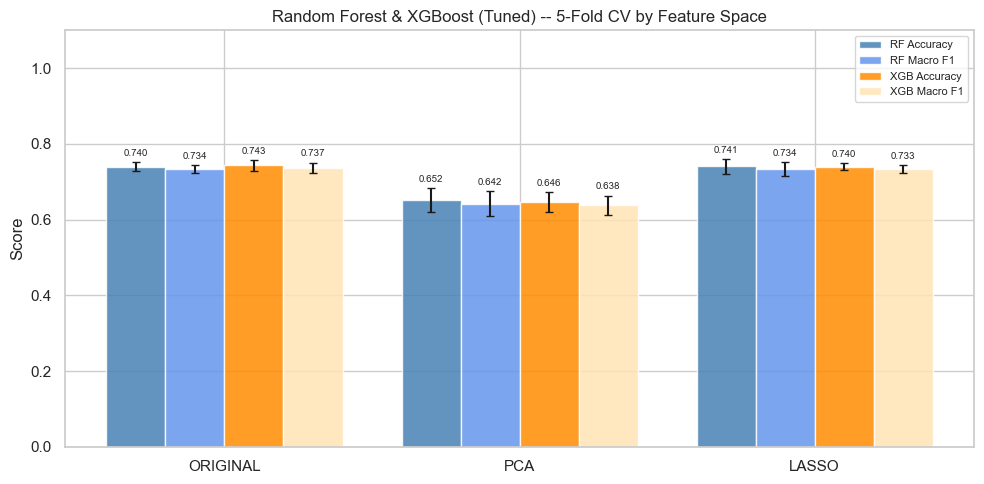

In [45]:
fs_labels = list(feature_sets.keys())
x     = np.arange(len(fs_labels))
width = 0.2
colors = {"Random Forest": ("steelblue", "cornflowerblue"),
          "XGBoost"      : ("darkorange", "moccasin")}

fig, ax = plt.subplots(figsize=(10, 5))
offsets = [-1.5, -0.5, 0.5, 1.5]
bars_meta = [
    ("Random Forest", "acc", offsets[0], colors["Random Forest"][0], "RF Accuracy"),
    ("Random Forest", "f1",  offsets[1], colors["Random Forest"][1], "RF Macro F1"),
    ("XGBoost",       "acc", offsets[2], colors["XGBoost"][0],       "XGB Accuracy"),
    ("XGBoost",       "f1",  offsets[3], colors["XGBoost"][1],       "XGB Macro F1"),
]

for model_name, metric, offset, color, label in bars_meta:
    means = [cv_results_tuned[model_name][fs][f"{metric}_mean"] for fs in fs_labels]
    stds  = [cv_results_tuned[model_name][fs][f"{metric}_std"]  for fs in fs_labels]
    bars = ax.bar(x + offset * width, means, width, yerr=stds, capsize=3,
                  label=label, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([f.upper() for f in fs_labels])
ax.set_ylabel("Score")
ax.set_title("Random Forest & XGBoost (Tuned) -- 5-Fold CV by Feature Space")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/06-Forests/forests_cv_comparison_tuned.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
joblib.dump(cv_results_tuned, '../data/processed/cv_results_forests_tuned.pkl')

# Re-train tuned models on full training set for use in notebook 08
trained_models_tuned = {}
for model_name, (model, param_dist, use_sw) in tuned_models_config.items():
    trained_models_tuned[model_name] = {}
    for fs_name, fs in feature_sets.items():
        best_params = cv_results_tuned[model_name][fs_name]['best_params']
        m = clone(model).set_params(**best_params)
        fit_kwargs = {}
        if use_sw:
            fit_kwargs['sample_weight'] = compute_sample_weight('balanced', y_train)
        m.fit(fs['X_train'], y_train.values, **fit_kwargs)
        trained_models_tuned[model_name][fs_name] = m
        print(f'Trained tuned {model_name} ({fs_name})')

joblib.dump(trained_models_tuned, '../data/processed/trained_models_forests_tuned.pkl')
print('\nTuned results and models saved to data/processed/')

Trained tuned Random Forest (original)
Trained tuned Random Forest (pca)
Trained tuned Random Forest (lasso)
Trained tuned XGBoost (original)
Trained tuned XGBoost (pca)
Trained tuned XGBoost (lasso)

Tuned results and models saved to data/processed/
